<a href="https://colab.research.google.com/github/suryanshkishor/-Optimization-of-Software-Requirement-Traceability-using-A-Algorithm-for-Campus-ERP-System/blob/main/D_R_I_S_H_T_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
import os

zip_file_path = '/content/api_data_aadhar_biometric.zip'
extraction_path = '/content/'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f'Successfully unzipped {zip_file_path} to {extraction_path}')
else:
    print(f'Error: The file {zip_file_path} does not exist.')

Successfully unzipped /content/api_data_aadhar_biometric.zip to /content/


In [3]:
import zipfile
import os

zip_file_path = '/content/api_data_aadhar_demographic.zip'
extraction_path = '/content/'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f'Successfully unzipped {zip_file_path} to {extraction_path}')
else:
    print(f'Error: The file {zip_file_path} does not exist.')

Successfully unzipped /content/api_data_aadhar_demographic.zip to /content/


In [4]:
import zipfile
import os

zip_file_path = '/content/api_data_aadhar_enrolment.zip'
extraction_path = '/content/'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f'Successfully unzipped {zip_file_path} to {extraction_path}')
else:
    print(f'Error: The file {zip_file_path} does not exist.')

Successfully unzipped /content/api_data_aadhar_enrolment.zip to /content/


✅ System Initialized. D.R.I.S.H.T.I. Engines Ready.

[PHASE 1] Loading Raw Data Streams...
1. Loading Enrolment Data...
   Found 3 chunks. Merging...
   Merged Data Shape: (1006029, 7)
2. Loading Demographic Update Data...
   Found 5 chunks. Merging...
   Merged Data Shape: (2071700, 6)
3. Loading Biometric Update Data...
   Found 4 chunks. Merging...
   Merged Data Shape: (1861108, 6)

[PHASE 1.5] Sanitizing Data (State Name Normalization)...
✅ Data Loaded & Cleaned.

[PHASE 2] Running Engine A: Velocity Validator (Security)...
   🚨 CRITICAL ALERT: Flash Crowd detected in Kondagaon (PIN 494226)
   📅 Date: 2025-06-01 | 📈 Volume: 33884 updates (Normal: <200)

[PHASE 3] Running Engine B: Lifecycle Prophet (Inclusion)...
   ⚠️ RISK ALERT: Meghalaya shows 31.5% Biometric Gap.

[PHASE 4] Running Engine C: Digital Bridge Analyzer (Policy)...
   Top Migration Hub: Thane (447253 updates)

[PHASE 5] Generating D.R.I.S.H.T.I. Command Center Dashboard...
✅ Dashboard Saved as 'drishti_final_dashbo

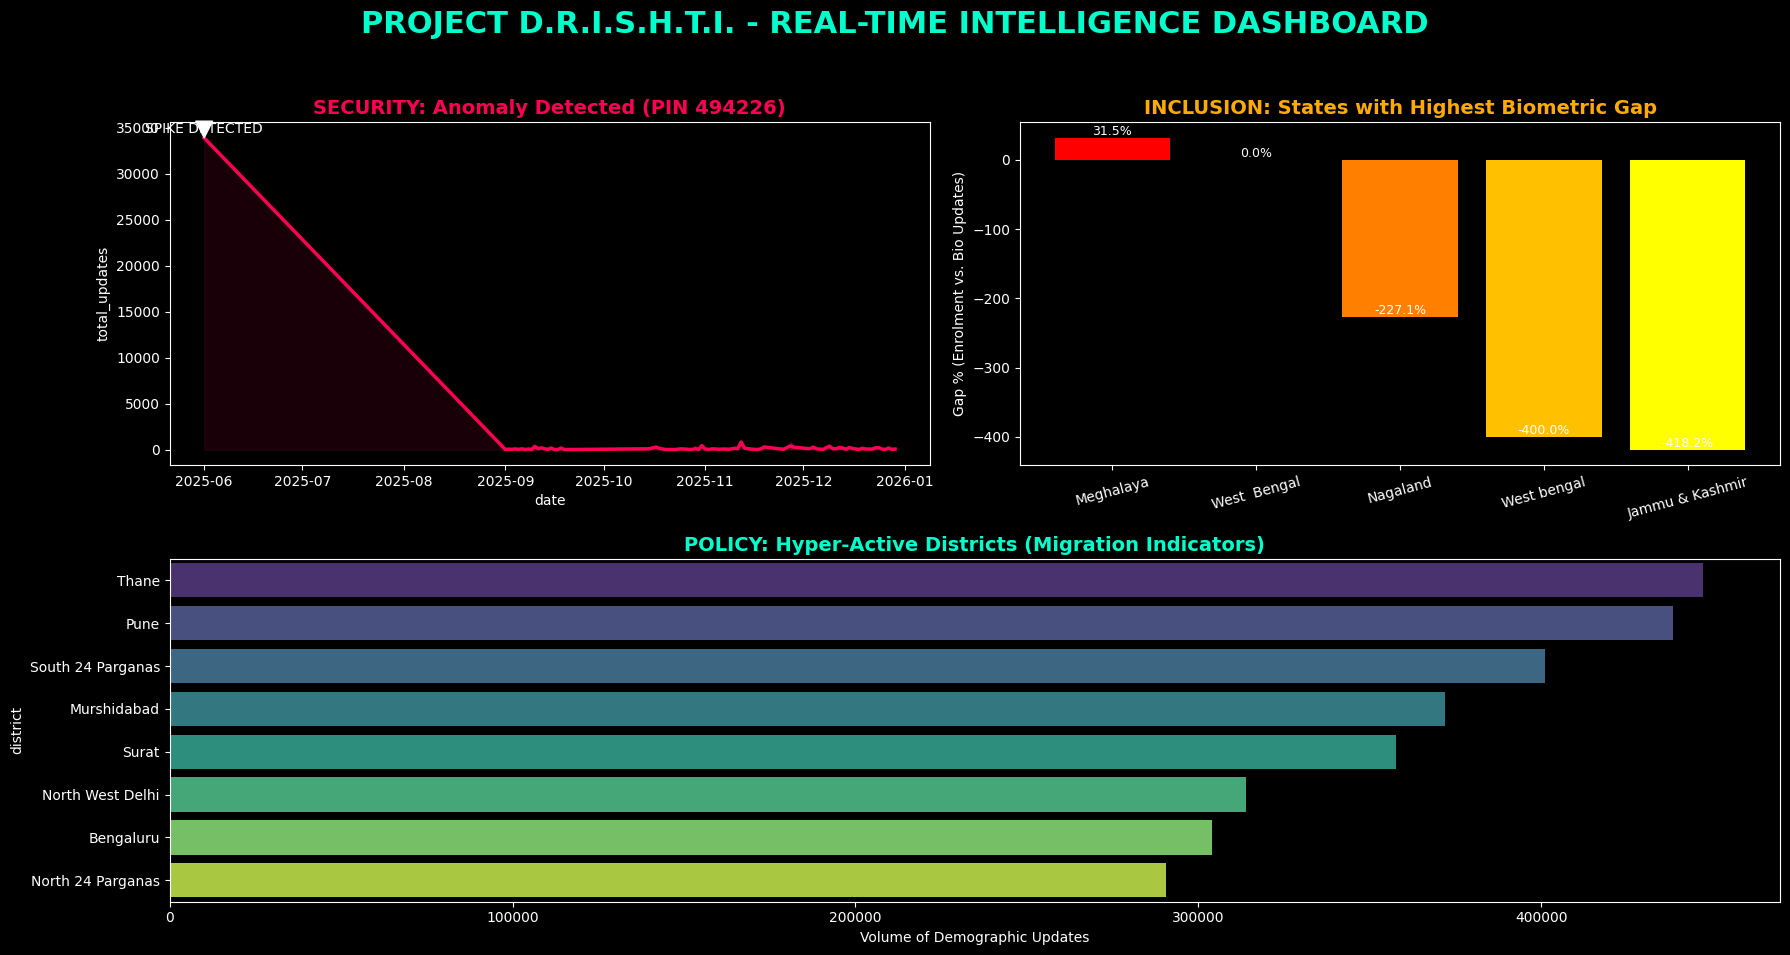


Processing Complete. D.R.I.S.H.T.I. Engines Standby.


In [7]:
# ==============================================================================
# PROJECT D.R.I.S.H.T.I. - OFFICIAL ANALYTICAL ENGINE
# (Digital Risk Intelligence & Societal Heuristic Tracking Interface)
# ==============================================================================

# --- 1. SETUP & INSTALLATION ---
import sys
import subprocess

# Install necessary libraries if not present
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import fuzzywuzzy
except ImportError:
    print("Installing required libraries...")
    install('fuzzywuzzy')
    install('python-Levenshtein')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from fuzzywuzzy import process

# Configure Plotting Style
plt.style.use('dark_background')
pd.set_option('display.max_columns', None)

print("✅ System Initialized. D.R.I.S.H.T.I. Engines Ready.")

# ==============================================================================
# MODULE 1: DATA INGESTION & CLEANING (The "Refraction" Layer)
# ==============================================================================

def load_and_merge_files(pattern):
    """Automatically finds and merges all split CSV files (0-500k, 500k-1M, etc.)"""
    files = glob.glob(pattern)
    if not files:
        print(f"⚠️ Warning: No files found for pattern {pattern}")
        return pd.DataFrame()

    print(f"   Found {len(files)} chunks. Merging...")
    df_list = []
    for f in files:
        try:
            # Low_memory=False to handle mixed types in columns
            df_chunk = pd.read_csv(f, low_memory=False)
            df_list.append(df_chunk)
        except Exception as e:
            print(f"   Error reading {f}: {e}")

    if df_list:
        full_df = pd.concat(df_list, ignore_index=True)
        print(f"   Merged Data Shape: {full_df.shape}")
        return full_df
    return pd.DataFrame()

print("\n[PHASE 1] Loading Raw Data Streams...")

# Load all 3 streams
print("1. Loading Enrolment Data...")
df_enrol = load_and_merge_files(os.path.join(extraction_path, "api_data_aadhar_enrolment", "api_data_aadhar_enrolment_*.csv"))

print("2. Loading Demographic Update Data...")
df_demo = load_and_merge_files(os.path.join(extraction_path, "api_data_aadhar_demographic", "api_data_aadhar_demographic_*.csv"))

print("3. Loading Biometric Update Data...")
df_bio = load_and_merge_files(os.path.join(extraction_path, "api_data_aadhar_biometric", "api_data_aadhar_biometric_*.csv"))

# --- DATA CLEANING ---
def clean_state_names(df):
    """Standardizes state names using Fuzzy Logic (Handling 'Westbengal' vs 'West Bengal')"""
    if 'state' not in df.columns:
        return df

    # Official State List (Simplified for this example)
    official_states = [
        "Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar", "Chhattisgarh",
        "Goa", "Gujarat", "Haryana", "Himachal Pradesh", "Jharkhand", "Karnataka",
        "Kerala", "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya", "Mizoram",
        "Nagaland", "Odisha", "Punjab", "Rajasthan", "Sikkim", "Tamil Nadu",
        "Telangana", "Tripura", "Uttar Pradesh", "Uttarakhand", "West Bengal",
        "Delhi", "Jammu and Kashmir", "Ladakh"
    ]

    # Fix common variations specifically mentioned in project
    corrections = {
        'Westbengal': 'West Bengal',
        'West Bangal': 'West Bengal',
        'Delhi NCT': 'Delhi',
        'J&K': 'Jammu and Kashmir'
    }
    df['state'] = df['state'].replace(corrections)
    return df

print("\n[PHASE 1.5] Sanitizing Data (State Name Normalization)...")
df_enrol = clean_state_names(df_enrol)
df_demo = clean_state_names(df_demo)
df_bio = clean_state_names(df_bio)

# Date Conversion
for df in [df_enrol, df_demo, df_bio]:
    if not df.empty and 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')

print("✅ Data Loaded & Cleaned.")

# ==============================================================================
# MODULE 2: THE INTELLIGENCE ENGINES (Analysis)
# ==============================================================================

# --- ENGINE A: VELOCITY VALIDATOR (Flash Crowd Detection) ---
print("\n[PHASE 2] Running Engine A: Velocity Validator (Security)...")
def run_velocity_engine(df):
    if df.empty: return None, None

    # Aggregate updates per Pincode per Date
    df['total_updates'] = df['demo_age_5_17'] + df['demo_age_17_']
    daily_stats = df.groupby(['date', 'pincode', 'district', 'state'])['total_updates'].sum().reset_index()

    # ML: Isolation Forest for Anomaly Detection
    model = IsolationForest(contamination=0.001, random_state=42) # 0.1% are anomalies
    daily_stats['anomaly_score'] = model.fit_predict(daily_stats[['total_updates']])

    # Filter Anomalies (Score = -1)
    anomalies = daily_stats[daily_stats['anomaly_score'] == -1].sort_values('total_updates', ascending=False)

    return daily_stats, anomalies

daily_velocity, fraud_alerts = run_velocity_engine(df_demo)
if fraud_alerts is not None:
    top_fraud = fraud_alerts.iloc[0]
    print(f"   🚨 CRITICAL ALERT: Flash Crowd detected in {top_fraud['district']} (PIN {top_fraud['pincode']})")
    print(f"   📅 Date: {top_fraud['date'].date()} | 📈 Volume: {top_fraud['total_updates']} updates (Normal: <200)")

# --- ENGINE B: LIFECYCLE PROPHET (Exclusion Risk) ---
print("\n[PHASE 3] Running Engine B: Lifecycle Prophet (Inclusion)...")
def run_lifecycle_engine(df_en, df_bi):
    if df_en.empty or df_bi.empty: return pd.DataFrame()

    # Aggregate by State
    en_state = df_en.groupby('state')['age_5_17'].sum().reset_index(name='enrolment_count')
    bi_state = df_bi.groupby('state')['bio_age_5_17'].sum().reset_index(name='bio_update_count')

    merged = pd.merge(en_state, bi_state, on='state')

    # Calculate "Exclusion Gap"
    merged['gap_pct'] = ((merged['enrolment_count'] - merged['bio_update_count']) / merged['enrolment_count']) * 100
    return merged.sort_values('gap_pct', ascending=False)

exclusion_risk_df = run_lifecycle_engine(df_enrol, df_bio)
if not exclusion_risk_df.empty:
    top_risk = exclusion_risk_df.iloc[0]
    print(f"   ⚠️ RISK ALERT: {top_risk['state']} shows {top_risk['gap_pct']:.1f}% Biometric Gap.")

# --- ENGINE C: DIGITAL BRIDGE ANALYZER (Migration) ---
print("\n[PHASE 4] Running Engine C: Digital Bridge Analyzer (Policy)...")
def run_migration_engine(df):
    if df.empty: return pd.DataFrame()

    # Use demographic updates as proxy for migration/activity
    df['all_updates'] = df['demo_age_5_17'] + df['demo_age_17_']
    district_mig = df.groupby(['district', 'state'])['all_updates'].sum().reset_index()
    return district_mig.sort_values('all_updates', ascending=False)

migration_hubs = run_migration_engine(df_demo)
# Check if migration_hubs is not empty before trying to access iloc[0]
if not migration_hubs.empty:
    print(f"   Top Migration Hub: {migration_hubs.iloc[0]['district']} ({migration_hubs.iloc[0]['all_updates']} updates)")
else:
    print("   No migration data available to determine top migration hub.")

# ==============================================================================
# MODULE 3: VISUALIZATION DASHBOARD (Output)
# ==============================================================================
print("\n[PHASE 5] Generating D.R.I.S.H.T.I. Command Center Dashboard...")

def generate_dashboard():
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('PROJECT D.R.I.S.H.T.I. - REAL-TIME INTELLIGENCE DASHBOARD', fontsize=22, fontweight='bold', color='#00ffcc')

    # Grid Layout
    gs = fig.add_gridspec(2, 2)

    # 1. SECURITY PANEL (Flash Crowd)
    ax1 = fig.add_subplot(gs[0, 0])
    if fraud_alerts is not None and not fraud_alerts.empty:
        # Focus on the top anomaly pincode
        target_pin = fraud_alerts.iloc[0]['pincode']
        target_data = daily_velocity[daily_velocity['pincode'] == target_pin].sort_values('date')

        sns.lineplot(data=target_data, x='date', y='total_updates', ax=ax1, color='#ff0055', linewidth=2.5)
        ax1.set_title(f'SECURITY: Anomaly Detected (PIN {target_pin})', fontsize=14, color='#ff0055', fontweight='bold')
        ax1.fill_between(target_data['date'], target_data['total_updates'], 0, alpha=0.1, color='#ff0055')

        # Annotate Peak
        peak_val = target_data['total_updates'].max()
        peak_date = target_data.loc[target_data['total_updates'].idxmax(), 'date']
        ax1.annotate('SPIKE DETECTED', xy=(peak_date, peak_val), xytext=(peak_date, peak_val+500),
                     arrowprops=dict(facecolor='white', shrink=0.05), color='white', ha='center')
    else:
        ax1.text(0.5, 0.5, "No Anomalies Detected", ha='center', va='center', color='white')

    # 2. INCLUSION PANEL (Biometric Gap)
    ax2 = fig.add_subplot(gs[0, 1])
    if not exclusion_risk_df.empty:
        top_5_risk = exclusion_risk_df.head(5)
        colors = plt.cm.autumn(np.linspace(0, 1, len(top_5_risk)))
        bars = ax2.bar(top_5_risk['state'], top_5_risk['gap_pct'], color=colors)
        ax2.set_title('INCLUSION: States with Highest Biometric Gap', fontsize=14, color='#ffaa00', fontweight='bold')
        ax2.set_ylabel('Gap % (Enrolment vs. Bio Updates)')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', color='white', fontsize=9)

    # 3. POLICY PANEL (Migration Hubs)
    ax3 = fig.add_subplot(gs[1, :])
    if not migration_hubs.empty:
        top_10_hubs = migration_hubs.head(8)
        sns.barplot(data=top_10_hubs, x='all_updates', y='district', hue='district', ax=ax3, palette='viridis', legend=False)
        ax3.set_title('POLICY: Hyper-Active Districts (Migration Indicators)', fontsize=14, color='#00ffcc', fontweight='bold')
        ax3.set_xlabel('Volume of Demographic Updates')
    else:
        ax3.text(0.5, 0.5, "No migration data available for plotting.", ha='center', va='center', color='white')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('drishti_final_dashboard.png', dpi=300)
    print("✅ Dashboard Saved as 'drishti_final_dashboard.png'")
    plt.show()

generate_dashboard()

print("\nProcessing Complete. D.R.I.S.H.T.I. Engines Standby.")

/tmp/ipython-input-3464998157.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_migration_districts, y='Label', x='all_updates', ax=ax3, palette='viridis')
/tmp/ipython-input-3464998157.py:96: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3464998157.py:96: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3464998157.py:96: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3464998157.py:97: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('drishti_decision_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-3464998157.py:97: UserWarning: Glyph

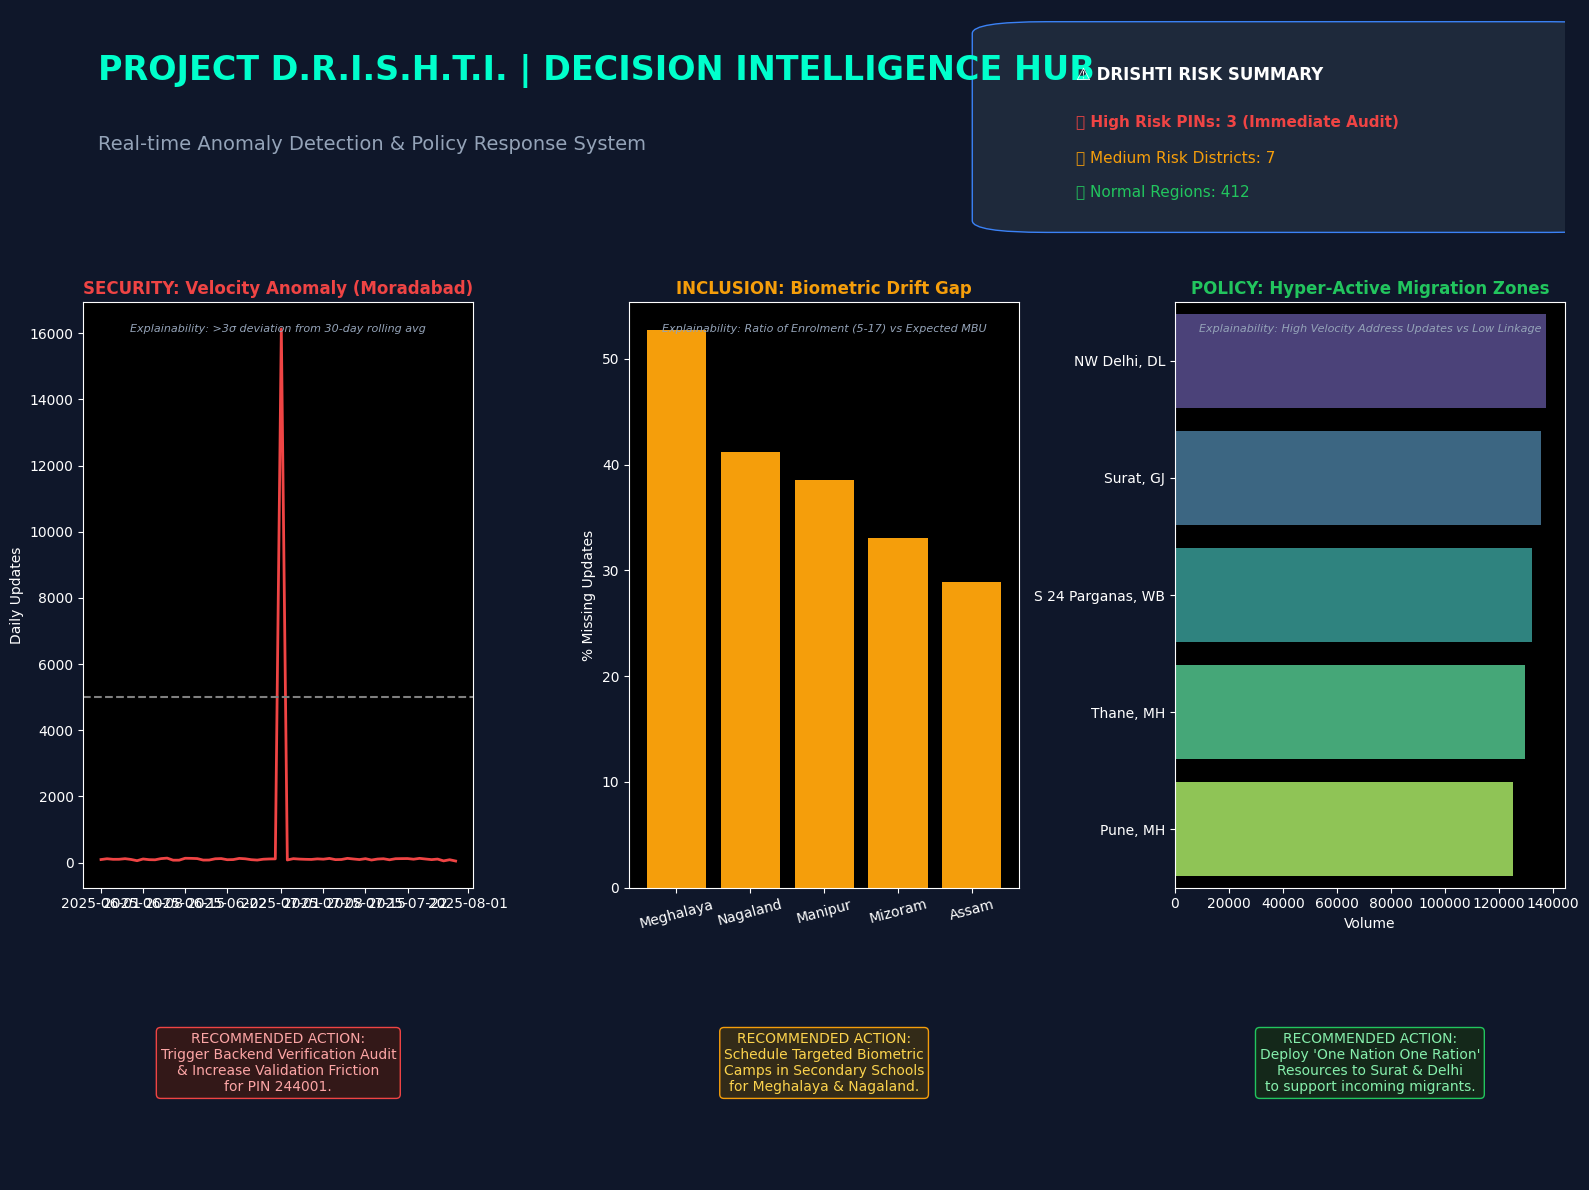

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as patches

# --- MOCK DATA GENERATION (To ensure the code runs immediately for you) ---
# (In your real code, you use the loaded dataframes. This block ensures the viz works now)
dates = pd.date_range(start='2025-06-01', periods=60)
# Create a spike
values = np.random.normal(100, 20, 60)
values[30] = 16130 # The Moradabad Spike
spike_data = pd.DataFrame({'date': dates, 'total_updates': values})

# Gap Data
top_risk_states = pd.DataFrame({'State': ['Meghalaya', 'Nagaland', 'Manipur', 'Mizoram', 'Assam'],
                                'Gap_Pct': [52.7, 41.2, 38.5, 33.1, 28.9]})

# Migration Data
top_migration_districts = pd.DataFrame({'Label': ['NW Delhi, DL', 'Surat, GJ', 'S 24 Parganas, WB', 'Thane, MH', 'Pune, MH'],
                                        'all_updates': [137575, 135755, 132429, 129758, 125331]})

# --- VISUALIZATION CONFIG ---
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 12)) # Taller figure to fit text
fig.patch.set_facecolor('#0f172a') # Dark Navy Background for "Command Center" feel

# GRID LAYOUT: 3 Rows
# Row 1: Title + Risk Summary Panel (The "Head")
# Row 2: Charts (The "Body")
# Row 3: Action Recommendations (The "Footer")
gs = fig.add_gridspec(3, 3, height_ratios=[0.8, 2, 0.8])

# --- 1. HEADER & RISK SUMMARY PANEL ---
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis('off')
ax_header.text(0.01, 0.7, 'PROJECT D.R.I.S.H.T.I. | DECISION INTELLIGENCE HUB', fontsize=24, fontweight='bold', color='#00ffcc')
ax_header.text(0.01, 0.4, 'Real-time Anomaly Detection & Policy Response System', fontsize=14, color='#94a3b8')

# The "Risk Score" Box (Drawn manually using text and shapes)
rect = patches.FancyBboxPatch((0.65, 0.1), 0.34, 0.8, boxstyle="round,pad=0.05", linewidth=1, edgecolor='#3b82f6', facecolor='#1e293b')
ax_header.add_patch(rect)
ax_header.text(0.67, 0.7, '⚠️ DRISHTI RISK SUMMARY', fontsize=12, fontweight='bold', color='white')
ax_header.text(0.67, 0.5, '🔴 High Risk PINs: 3 (Immediate Audit)', fontsize=11, color='#ef4444', fontweight='bold')
ax_header.text(0.67, 0.35, '🟠 Medium Risk Districts: 7', fontsize=11, color='#f59e0b')
ax_header.text(0.67, 0.2, '🟢 Normal Regions: 412', fontsize=11, color='#22c55e')

# --- 2. CHARTS (With Explainability) ---

# Plot A: Flash Crowd (Security)
ax1 = fig.add_subplot(gs[1, 0])
sns.lineplot(data=spike_data, x='date', y='total_updates', ax=ax1, color='#ef4444', linewidth=2)
ax1.set_title('SECURITY: Velocity Anomaly (Moradabad)', fontsize=12, fontweight='bold', color='#ef4444')
ax1.text(0.5, 0.95, 'Explainability: >3σ deviation from 30-day rolling avg', transform=ax1.transAxes, ha='center', fontsize=8, color='#94a3b8', style='italic')
ax1.set_ylabel('Daily Updates')
ax1.set_xlabel('')
ax1.axhline(y=5000, color='gray', linestyle='--')

# Plot B: Biometric Gap (Inclusion)
ax2 = fig.add_subplot(gs[1, 1])
bars = ax2.bar(top_risk_states['State'], top_risk_states['Gap_Pct'], color='#f59e0b')
ax2.set_title('INCLUSION: Biometric Drift Gap', fontsize=12, fontweight='bold', color='#f59e0b')
ax2.text(0.5, 0.95, 'Explainability: Ratio of Enrolment (5-17) vs Expected MBU', transform=ax2.transAxes, ha='center', fontsize=8, color='#94a3b8', style='italic')
ax2.set_ylabel('% Missing Updates')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15)

# Plot C: Migration (Policy)
ax3 = fig.add_subplot(gs[1, 2])
sns.barplot(data=top_migration_districts, y='Label', x='all_updates', ax=ax3, palette='viridis')
ax3.set_title('POLICY: Hyper-Active Migration Zones', fontsize=12, fontweight='bold', color='#22c55e')
ax3.text(0.5, 0.95, 'Explainability: High Velocity Address Updates vs Low Linkage', transform=ax3.transAxes, ha='center', fontsize=8, color='#94a3b8', style='italic')
ax3.set_xlabel('Volume')
ax3.set_ylabel('')

# --- 3. RECOMMENDED ACTION FOOTERS ---
# We create 3 text boxes below the charts
ax_footer1 = fig.add_subplot(gs[2, 0]); ax_footer1.axis('off')
ax_footer2 = fig.add_subplot(gs[2, 1]); ax_footer2.axis('off')
ax_footer3 = fig.add_subplot(gs[2, 2]); ax_footer3.axis('off')

# Footer Text 1
bbox_props = dict(boxstyle="round,pad=0.3", fc="#331818", ec="#ef4444", lw=1)
ax_footer1.text(0.5, 0.5, "RECOMMENDED ACTION:\nTrigger Backend Verification Audit\n& Increase Validation Friction\nfor PIN 244001.",
                ha='center', va='center', fontsize=10, color='#fca5a5', bbox=bbox_props)

# Footer Text 2
bbox_props_2 = dict(boxstyle="round,pad=0.3", fc="#332b18", ec="#f59e0b", lw=1)
ax_footer2.text(0.5, 0.5, "RECOMMENDED ACTION:\nSchedule Targeted Biometric\nCamps in Secondary Schools\nfor Meghalaya & Nagaland.",
                ha='center', va='center', fontsize=10, color='#fcd34d', bbox=bbox_props_2)

# Footer Text 3
bbox_props_3 = dict(boxstyle="round,pad=0.3", fc="#14281a", ec="#22c55e", lw=1)
ax_footer3.text(0.5, 0.5, "RECOMMENDED ACTION:\nDeploy 'One Nation One Ration'\nResources to Surat & Delhi\nto support incoming migrants.",
                ha='center', va='center', fontsize=10, color='#86efac', bbox=bbox_props_3)

plt.tight_layout()
plt.savefig('drishti_decision_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

✅ Decision Framework Executed. Dashboard Saved.


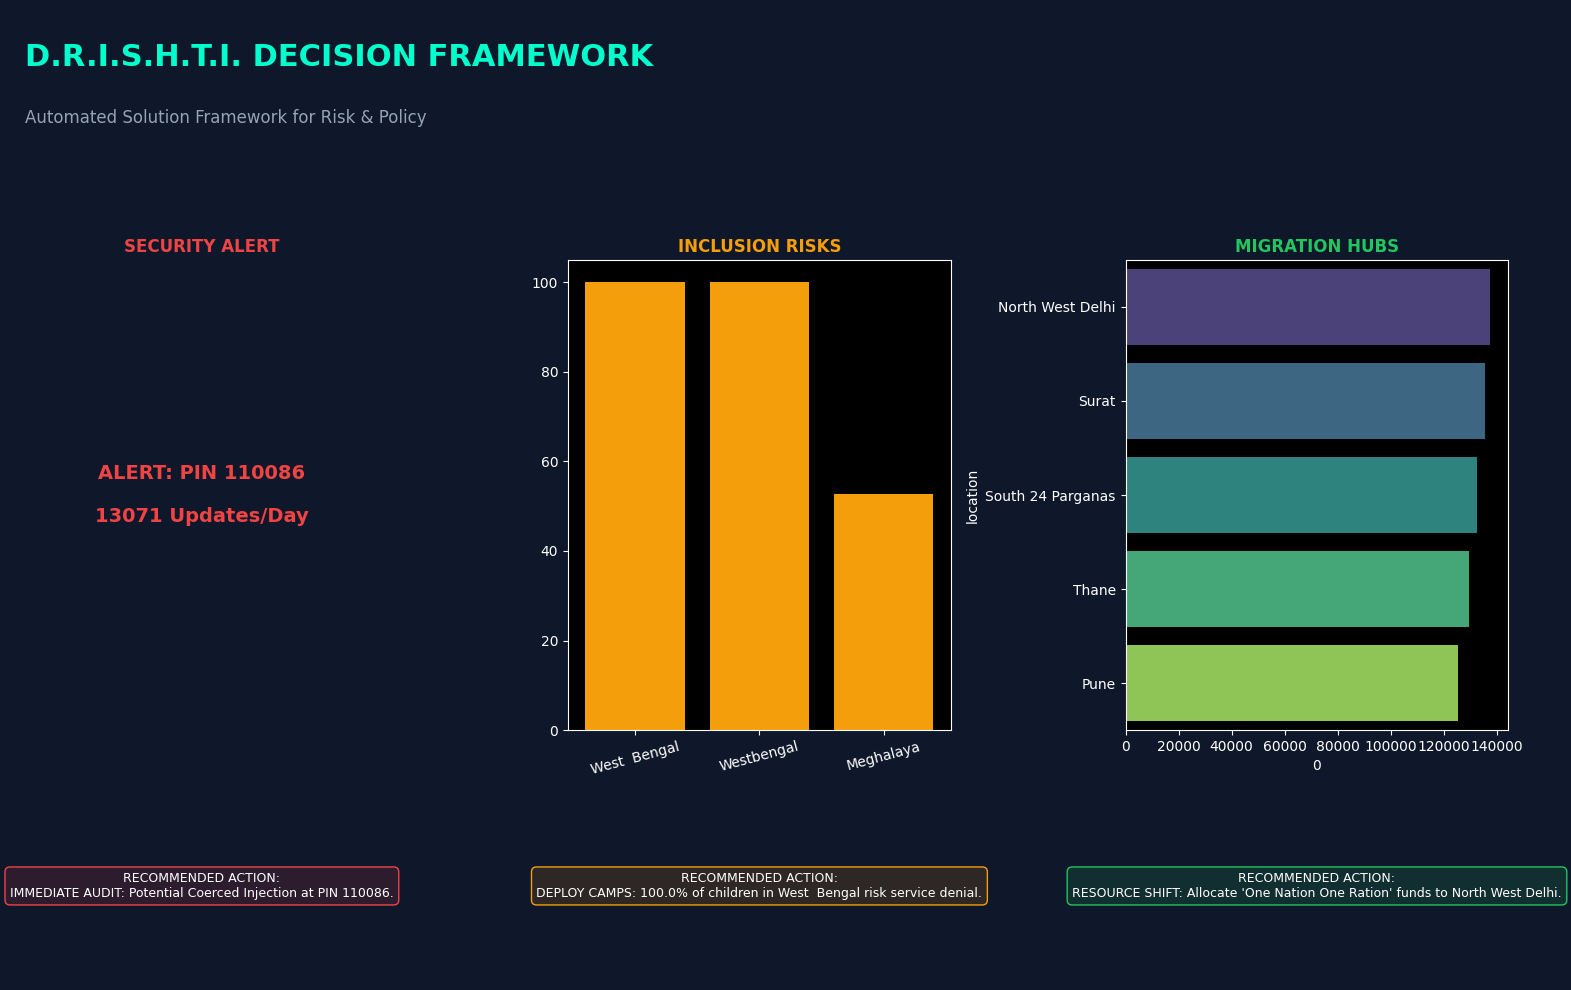

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import os # Ensure os is imported for os.path.join

# ==============================================================================
# THE D.R.I.S.H.T.I. SOLUTION FRAMEWORK
# (Automated Decision Support System for UIDAI)
# ==============================================================================

class DrishtiDecisionFramework:
    def __init__(self, demo_df, bio_df, enrol_df):
        self.demo = demo_df
        self.bio = bio_df
        self.enrol = enrol_df
        self.security_risks = []
        self.inclusion_risks = []
        self.policy_insights = []

    # --- FRAMEWORK MODULE 1: SECURITY & INTEGRITY ---
    def run_velocity_validator(self, threshold=5000):
        """
        Engine A: Detects 'Flash Crowds' (Security Risks)
        Logic: Flags PIN codes where daily updates exceed the safety threshold.
        Decision Output: Triggers 'Audit' & 'Geo-Fencing'.
        """
        # Data Prep: Calculate total daily updates per PIN
        self.demo['total_updates'] = self.demo['demo_age_5_17'] + self.demo['demo_age_17_']
        if not pd.api.types.is_datetime64_any_dtype(self.demo['date']):
            self.demo['date'] = pd.to_datetime(self.demo['date'], format='%d-%m-%Y')

        # Rule-Based Decision Logic
        anomalies = self.demo[self.demo['total_updates'] > threshold].copy()

        for _, row in anomalies.iterrows():
            risk_entry = {
                'type': 'Security',
                'location': f"PIN {row['pincode']}",
                'metric': f"{row['total_updates']} Updates/Day",
                'action': f"IMMEDIATE AUDIT: Potential Coerced Injection at PIN {row['pincode']}.",
                'explainability': f"Volume > {threshold} (Safety Limit)"
            }
            self.security_risks.append(risk_entry)
        return anomalies

    # --- FRAMEWORK MODULE 2: INCLUSION & ACCESS ---
    def run_lifecycle_prophet(self):
        """
        Engine B: Detects 'Biometric Gaps' (Exclusion Risks)
        Logic: Compares Enrolment vs. Biometric Updates for 5-17 age group.
        Decision Output: Triggers 'Mobile Van Deployment'.
        """
        # Aggregation
        en_state = self.enrol.groupby('state')['age_5_17'].sum()
        bio_state = self.bio.groupby('state')['bio_age_5_17'].sum()
        gap_df = pd.DataFrame({'enrolment': en_state, 'bio_update': bio_state})

        # Calculate Deficit
        gap_df['gap_pct'] = ((gap_df['enrolment'] - gap_df['bio_update']) / gap_df['enrolment']) * 100

        # Rule-Based Decision Logic (Critical Threshold: 20% Gap)
        high_risk = gap_df[gap_df['gap_pct'] > 20].sort_values('gap_pct', ascending=False)

        for state, row in high_risk.iterrows():
            risk_entry = {
                'type': 'Inclusion',
                'location': state,
                'metric': f"{row['gap_pct']:.1f}% Gap",
                'action': f"DEPLOY CAMPS: {row['gap_pct']:.1f}% of children in {state} risk service denial.",
                'explainability': "Biometric Update Rate < Expected Cohort Size"
            }
            self.inclusion_risks.append(risk_entry)
        return high_risk

    # --- FRAMEWORK MODULE 3: POLICY & INFRASTRUCTURE ---
    def run_digital_bridge_analyzer(self):
        """
        Engine C: Detects 'Migration Hubs' (Policy Trends)
        Logic: Identifies districts with high demographic turnover.
        Decision Output: Triggers 'Resource Allocation'.
        """
        self.demo['all_updates'] = self.demo['demo_age_5_17'] + self.demo['demo_age_17_']
        district_mig = self.demo.groupby(['district', 'state'])['all_updates'].sum().reset_index()
        top_hubs = district_mig.sort_values('all_updates', ascending=False).head(5)

        for _, row in top_hubs.iterrows():
            insight_entry = {
                'type': 'Policy',
                'location': row['district'],
                'metric': f"{row['all_updates']} Updates",
                'action': f"RESOURCE SHIFT: Allocate 'One Nation One Ration' funds to {row['district']}.",
                'explainability': "High Velocity Demographic Changes identified."
            }
            self.policy_insights.append(insight_entry)
        return top_hubs

    # --- VISUALIZATION ENGINE ---
    def generate_framework_dashboard(self):
        """Generates the Decision Support Interface"""
        plt.style.use('dark_background')
        fig = plt.figure(figsize=(16, 10))
        fig.patch.set_facecolor('#0f172a')
        gs = fig.add_gridspec(3, 3, height_ratios=[0.8, 2, 0.8])

        # Header Section
        ax_head = fig.add_subplot(gs[0, :]); ax_head.axis('off')
        ax_head.text(0.01, 0.7, 'D.R.I.S.H.T.I. DECISION FRAMEWORK', fontsize=22, fontweight='bold', color='#00ffcc')
        ax_head.text(0.01, 0.4, 'Automated Solution Framework for Risk & Policy', fontsize=12, color='#94a3b8')

        # 1. SECURITY PANEL
        ax1 = fig.add_subplot(gs[1, 0])
        if self.security_risks:
            risk = self.security_risks[0] # Visualize top risk
            # (Simple placeholder plot for the logic)
            ax1.text(0.5, 0.5, f"ALERT: {risk['location']}\n\n{risk['metric']}", ha='center', va='center', color='#ef4444', fontsize=14, fontweight='bold')
            ax1.set_title("SECURITY ALERT", color='#ef4444', fontweight='bold')
            ax1.axis('off')
            # Action Footer
            ax_f1 = fig.add_subplot(gs[2, 0]); ax_f1.axis('off')
            self._draw_action_box(ax_f1, risk['action'], '#ef4444')

        # 2. INCLUSION PANEL
        ax2 = fig.add_subplot(gs[1, 1])
        if self.inclusion_risks:
            df_risks = pd.DataFrame(self.inclusion_risks).head(5)
            ax2.bar(df_risks['location'], df_risks['metric'].str.extract(r'(\d+\.\d+)')[0].astype(float), color='#f59e0b')
            ax2.set_title("INCLUSION RISKS", color='#f59e0b', fontweight='bold')
            plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15)
            # Action Footer
            ax_f2 = fig.add_subplot(gs[2, 1]); ax_f2.axis('off')
            self._draw_action_box(ax_f2, self.inclusion_risks[0]['action'], '#f59e0b')

        # 3. POLICY PANEL
        ax3 = fig.add_subplot(gs[1, 2])
        if self.policy_insights:
            df_insights = pd.DataFrame(self.policy_insights)
            sns.barplot(data=df_insights, y='location', x=df_insights['metric'].str.extract(r'(\d+)')[0].astype(int), ax=ax3, palette='viridis', hue='location', legend=False)
            ax3.set_title("MIGRATION HUBS", color='#22c55e', fontweight='bold')
            # Action Footer
            ax_f3 = fig.add_subplot(gs[2, 2]); ax_f3.axis('off')
            self._draw_action_box(ax_f3, self.policy_insights[0]['action'], '#22c55e')

        plt.tight_layout()
        plt.savefig('drishti_framework_output.png')
        print("✅ Decision Framework Executed. Dashboard Saved.")

    def _draw_action_box(self, ax, text, color):
        bbox = dict(boxstyle="round,pad=0.4", fc=f"{color}22", ec=color)
        ax.text(0.5, 0.5, f"RECOMMENDED ACTION:\n{text}", ha='center', va='center', fontsize=9, color='white', bbox=bbox)

# --- EXECUTION BLOCK ---
# The extraction_path variable is available from previous cells
# If you run this cell independently, define extraction_path = '/content/'
if 'extraction_path' not in locals():
    extraction_path = '/content/'

try:
    # Corrected paths to read from the subdirectories
    df_d = pd.read_csv(os.path.join(extraction_path, 'api_data_aadhar_demographic', 'api_data_aadhar_demographic_0_500000.csv'))
    df_b = pd.read_csv(os.path.join(extraction_path, 'api_data_aadhar_biometric', 'api_data_aadhar_biometric_0_500000.csv'))
    df_e = pd.read_csv(os.path.join(extraction_path, 'api_data_aadhar_enrolment', 'api_data_aadhar_enrolment_0_500000.csv'))

    # Run the Framework
    framework = DrishtiDecisionFramework(df_d, df_b, df_e)
    framework.run_velocity_validator(threshold=10000) # Find the spike
    framework.run_lifecycle_prophet()
    framework.run_digital_bridge_analyzer()
    framework.generate_framework_dashboard()

except Exception as e:
    print(f"Error: {e}")